In [7]:
import pandas as pd
import numpy as np

# 1. Load the Data
filepath = "/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/594 Water Level Inst from 2022-01-01 to 2026-06-15.xlsx"
df_dgh = pd.read_excel(filepath, sheet_name=0)
df_dgh = df_dgh[['dateTime (NPT)', 'value (m)']].copy()
df_dgh.columns = ['DateTime', 'value']

In [8]:
# ==========================================
# 1. LOAD & CLEAN DGH DATA
# ==========================================
filepath = "/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/594 Water Level Inst from 2022-01-01 to 2026-06-15.xlsx"
df_dgh = pd.read_excel(filepath, sheet_name=0)
df_dgh = df_dgh[['dateTime (NPT)', 'value (m)']].copy()
df_dgh.columns = ['DateTime', 'value']

df_dgh['DateTime'] = pd.to_datetime(df_dgh['DateTime'])
df_dgh.sort_values('DateTime', inplace=True)
df_dgh.set_index('DateTime', inplace=True)

# Outlier Fix (No 10-min interpolation)
outlier_mask = (df_dgh['value'] > 20) | (df_dgh['value'] < 0.3)
df_dgh.loc[outlier_mask, 'value'] = np.nan

In [9]:
# ==========================================
# 2. DAILY AGGREGATION (The 1-reading rule)
# ==========================================
print("Aggregating to Daily MAX...")
# If even 1 reading exists, it takes the max. If all 144 are NaN, it returns NaN.
daily_dgh = df_dgh.resample('D').max()
daily_dgh.rename(columns={'value': 'Target_WaterLevel'}, inplace=True)

# Align to Golden Timeline
START_DATE = '2022-05-20'
END_DATE = '2025-11-05'
golden_index = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
daily_dgh = daily_dgh.reindex(golden_index)

Aggregating to Daily MAX...


In [10]:
# ==========================================
# 3. SMART INTERPOLATION (Max 4 Days)
# ==========================================
print("Applying Smart Gap Interpolation (<= 4 days only)...")
initial_nans = daily_dgh['Target_WaterLevel'].isna().sum()

# Identify gaps and their sizes
is_nan = daily_dgh['Target_WaterLevel'].isna()
gap_groups = is_nan.groupby((~is_nan).cumsum())
gap_sizes = gap_groups.transform('sum')

# Calculate standard interpolation
interpolated = daily_dgh['Target_WaterLevel'].interpolate(method='linear')

# Only apply interpolation where the gap is 4 days or less
daily_dgh['Target_WaterLevel'] = np.where(
    is_nan & (gap_sizes <= 4), 
    interpolated, 
    daily_dgh['Target_WaterLevel']
)

final_nans = daily_dgh['Target_WaterLevel'].isna().sum()
print(f" -> Interpolated {initial_nans - final_nans} short gaps.")
print(f" -> Left {final_nans} long-gap days untouched (Safe as NaN).")

Applying Smart Gap Interpolation (<= 4 days only)...
 -> Interpolated 15 short gaps.
 -> Left 24 long-gap days untouched (Safe as NaN).


In [11]:
# ==========================================
# 4. THE GRAND MERGE
# ==========================================
print("\nMerging with Meteorology Data...")
# Load the meteorology master we saved earlier
meteo_df = pd.read_csv('/kaggle/input/datasets/shishirpuri/meterology-kamala/meteorology_master_unscaled.csv', index_col=0, parse_dates=True)

# Combine both DataFrames (They perfectly align on the Date index)
twin_tower_df = pd.concat([daily_dgh, meteo_df], axis=1)

# Save the final pristine dataset
final_filename = 'twin_tower_dataset_unscaled.csv'
twin_tower_df.to_csv(final_filename)

print(f"\n✅ GRAND MERGE COMPLETE! Saved as '{final_filename}'")
print("-" * 50)
print(f"Final Shape: {twin_tower_df.shape} (Days, Features)")
print(f"Target Column: 'Target_WaterLevel' + 23 Meteo Features")
print("-" * 50)


Merging with Meteorology Data...

✅ GRAND MERGE COMPLETE! Saved as 'twin_tower_dataset_unscaled.csv'
--------------------------------------------------
Final Shape: (1266, 24) (Days, Features)
Target Column: 'Target_WaterLevel' + 23 Meteo Features
--------------------------------------------------


--- STEP 8: DEEP EDA OF MERGED DATASET ---

🔍 1. DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1266 entries, 2022-05-20 to 2025-11-05
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Target_WaterLevel     1242 non-null   float64
 1   Rain_Sindhuli         1266 non-null   float64
 2   Rain_BahunTilpung     1266 non-null   float64
 3   Rain_Tulsi            1266 non-null   float64
 4   Rain_Chisapani        1266 non-null   float64
 5   Rain_Janakpur         1266 non-null   float64
 6   Rain_Hardinath        1266 non-null   float64
 7   Rain_Lahan            1266 non-null   float64
 8   Rain_Siraha           1266 non-null   float64
 9   MaxT_SindhuliMadhi    1266 non-null   float64
 10  MaxT_JanakpurAirport  1266 non-null   float64
 11  MaxT_Hardinath        1266 non-null   float64
 12  MaxT_Lahan            1266 non-null   float64
 13  MaxT_Siraha           1266 non-null   floa

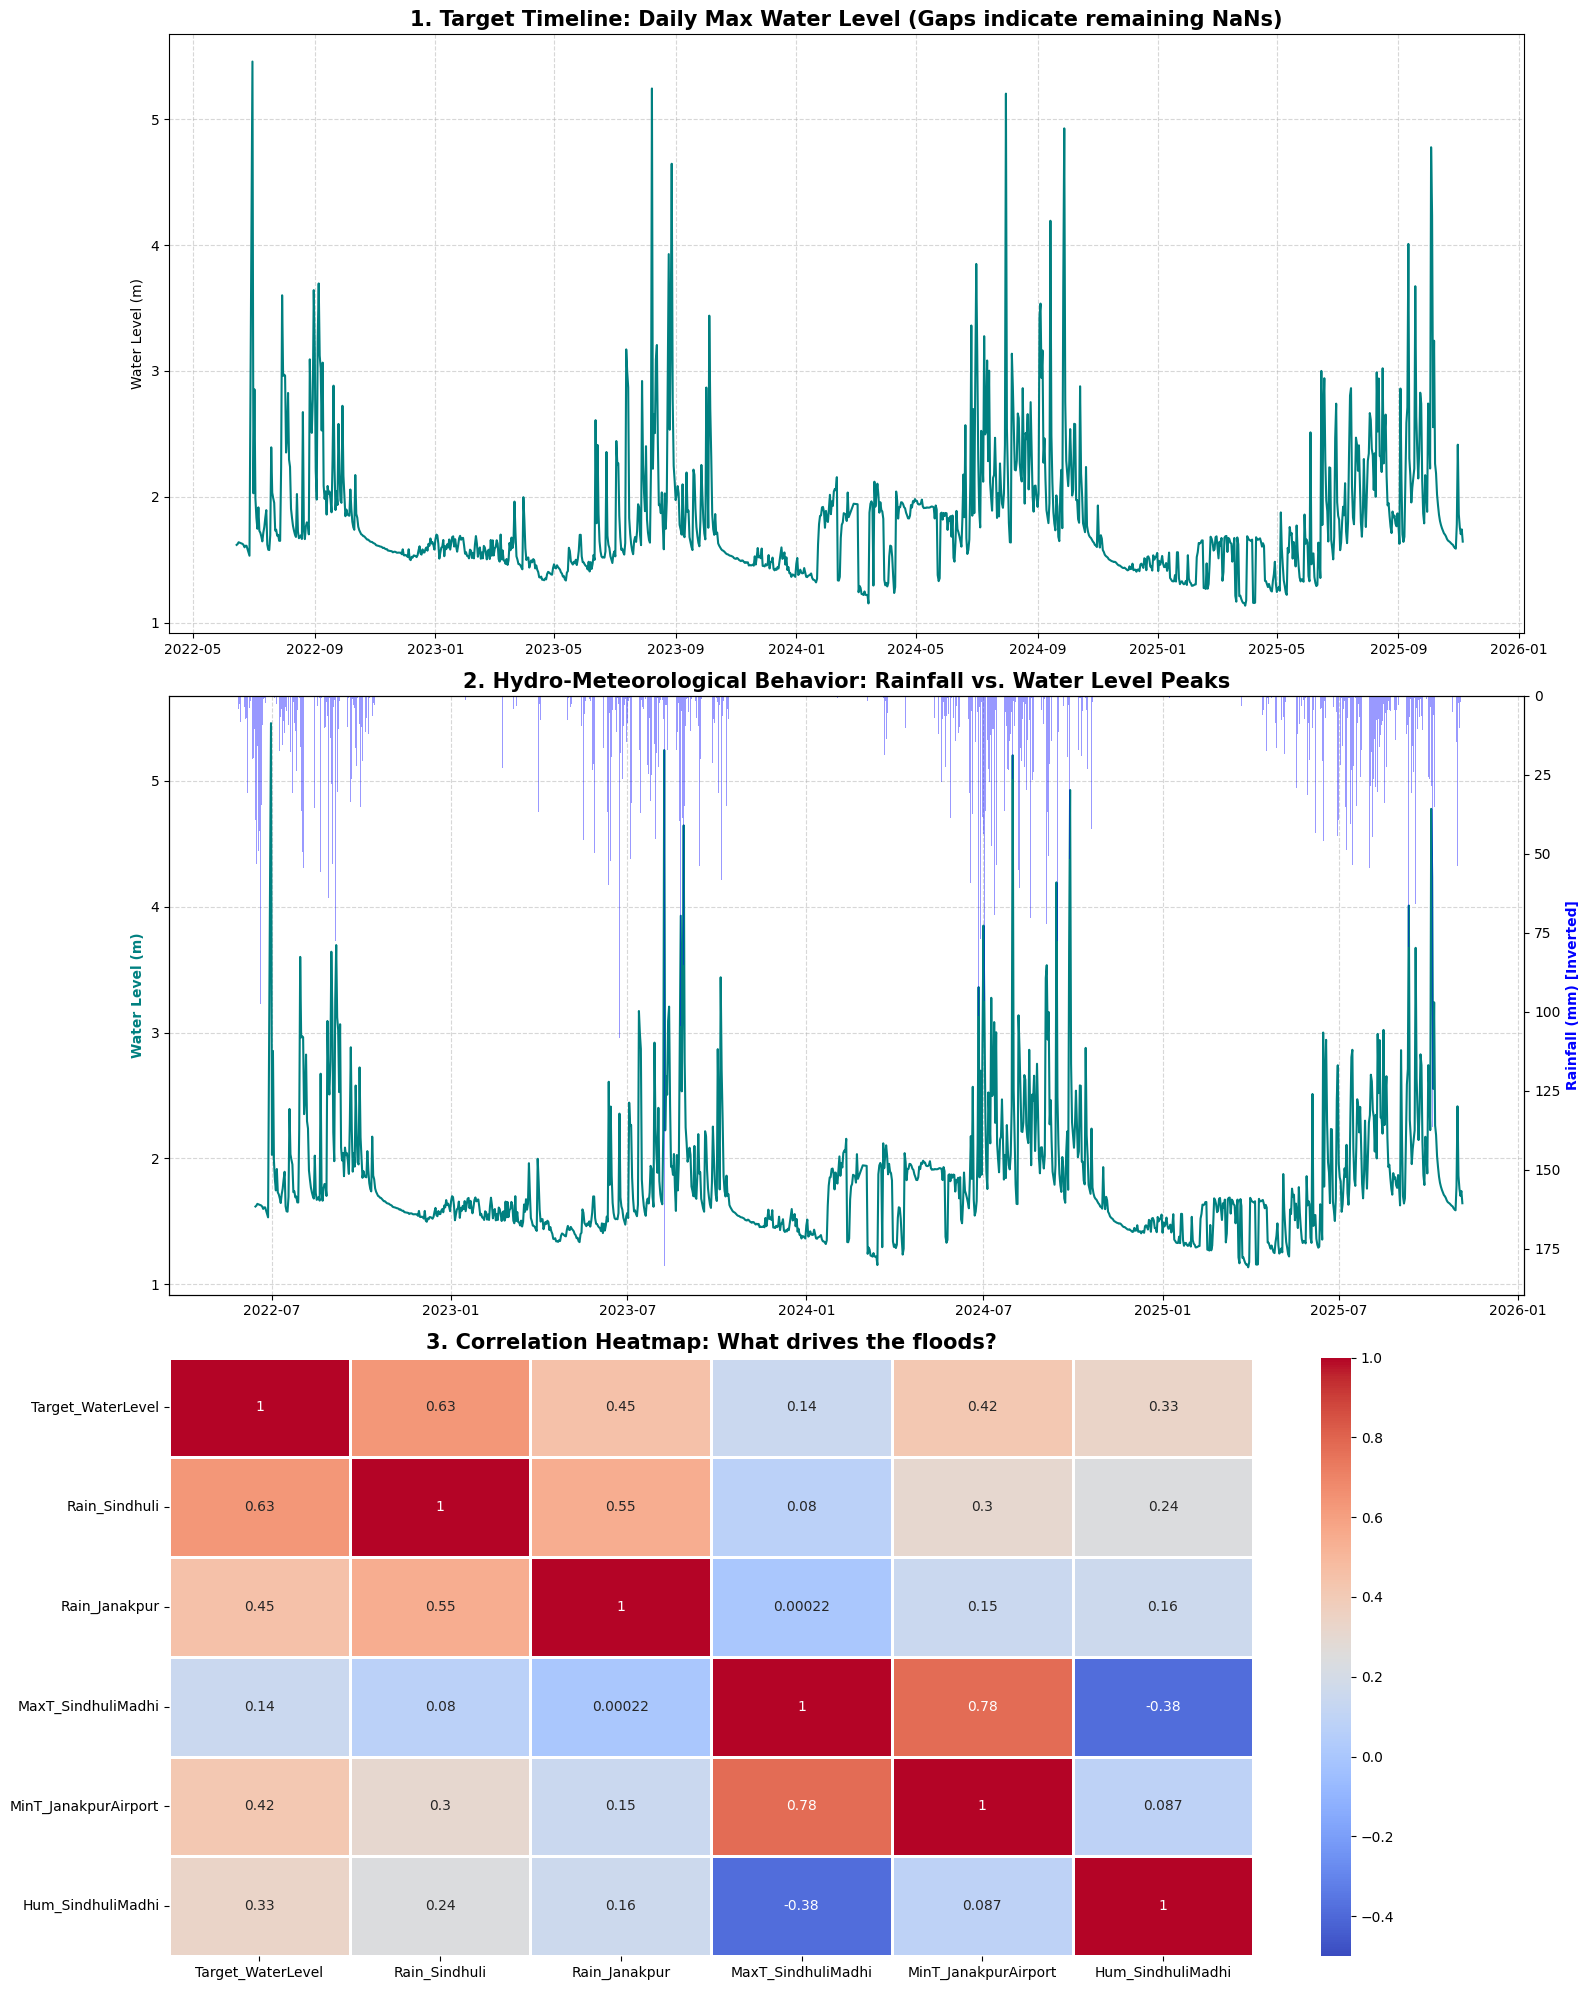

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- STEP 8: DEEP EDA OF MERGED DATASET ---")

# 1. Load the merged dataset
df = pd.read_csv('twin_tower_dataset_unscaled.csv', index_col=0, parse_dates=True)

# ==========================================
# TEXT-BASED PROFILING
# ==========================================
print("\n🔍 1. DATASET INFO:")
df.info()

print("\n🔍 2. MISSING VALUES CHECK (NaNs):")
nans = df.isna().sum()
print(nans[nans > 0]) # Only print columns that actually have NaNs

print("\n🔍 3. TARGET VARIABLE SUMMARY:")
print(df['Target_WaterLevel'].describe().round(2))

# ==========================================
# VISUAL PROFILING
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

# PLOT 1: The Target Timeline & Gap Visualization
axes[0].plot(df.index, df['Target_WaterLevel'], color='teal', linewidth=1.5)
axes[0].set_title('1. Target Timeline: Daily Max Water Level (Gaps indicate remaining NaNs)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Water Level (m)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PLOT 2: Cause & Effect (Classic Hydrology Hyetograph)
ax2_twin = axes[1].twinx()
axes[1].plot(df.index, df['Target_WaterLevel'], color='teal', label='Water Level (Kamala)')
# We plot upper catchment rain on the secondary axis
ax2_twin.bar(df.index, df['Rain_Sindhuli'], color='blue', alpha=0.4, label='Rainfall (Sindhuli)')
ax2_twin.invert_yaxis() # In hydrology, rainfall is drawn hanging from the top!

axes[1].set_title('2. Hydro-Meteorological Behavior: Rainfall vs. Water Level Peaks', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Water Level (m)', color='teal', fontweight='bold')
ax2_twin.set_ylabel('Rainfall (mm) [Inverted]', color='blue', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

# PLOT 3: Target vs Features Correlation Matrix
# Selecting a core subset of features for a clean, readable heatmap
core_cols = [
    'Target_WaterLevel', 'Rain_Sindhuli', 'Rain_Janakpur', 
    'MaxT_SindhuliMadhi', 'MinT_JanakpurAirport', 'Hum_SindhuliMadhi'
]
sns.heatmap(df[core_cols].corr(), annot=True, cmap='coolwarm', vmin=-0.5, vmax=1, ax=axes[2], linewidths=1)
axes[2].set_title('3. Correlation Heatmap: What drives the floods?', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()